# 02 — LoRA Rank Sweep on Banking77

Part of [bert-lora-finetuning](../README.md). Independent of `01_baseline...ipynb` — this notebook
loads its own data and only trains LoRA models, at several ranks. It doesn't need 01 to run, but the
accuracy plot is more useful with 01's full fine-tune number as a reference line.

**What this answers:** as rank `r` increases (more trainable parameters), how does accuracy change, and
where do returns start diminishing? This turns the single `r=8` number from notebook 01 into an actual
empirical curve instead of one point.

**Run on Colab or Kaggle with a GPU runtime.** This trains 4 separate LoRA models — expect roughly
4x the LoRA training time from notebook 01.

> **Kaggle: turn Internet on before running.** Sidebar → *Settings* → *Internet: On* (needs a
> phone-verified Kaggle account). With it off, pip and the HuggingFace Hub both fail with
> `Temporary failure in name resolution`, and pip then reports every package as
> `from versions: none` — that's a DNS failure, not a missing version. The preflight cell below
> checks this and tells you which mode you're in.

## Setup

In [1]:
# --- Preflight: environment, network, results dir -------------------------------------------
# Run this first. It diagnoses the two things that break this notebook on hosted runtimes:
# no internet, and a non-writable results path.
import os
import socket
import sys

def _resolves(host: str, timeout: float = 5.0) -> bool:
    """DNS probe that restores the global socket timeout it borrows.

    setdefaulttimeout() is process-wide: leaving it at 5s would silently apply to every
    later socket operation, including large model/dataset downloads.
    """
    previous = socket.getdefaulttimeout()
    socket.setdefaulttimeout(timeout)
    try:
        socket.gethostbyname(host)
        return True
    except OSError:
        return False
    finally:
        socket.setdefaulttimeout(previous)

ON_KAGGLE = os.path.isdir("/kaggle/working")
ON_COLAB = "google.colab" in sys.modules or os.path.isdir("/content")
ONLINE = _resolves("pypi.org")

# Only /kaggle/working is writable on Kaggle — the repo-relative "../results" resolves to
# /kaggle/results there and raises PermissionError on makedirs.
if ON_KAGGLE:
    BASE_DIR = "/kaggle/working"
elif ON_COLAB:
    BASE_DIR = "/content"
else:
    BASE_DIR = ".."            # notebook runs from notebooks/, so this is the repo root

RESULTS_DIR = f"{BASE_DIR}/results"          # CSV/JSON/PNG we keep and commit
SCRATCH_DIR = BASE_DIR                        # Trainer checkpoint dirs; gitignored, disposable
os.makedirs(RESULTS_DIR, exist_ok=True)

print(f"Environment : {'Kaggle' if ON_KAGGLE else 'Colab' if ON_COLAB else 'local'}")
print(f"Network     : {'online' if ONLINE else 'OFFLINE'}")
print(f"Results dir : {RESULTS_DIR}")
print(f"Scratch dir : {SCRATCH_DIR}/lora_sweep_r*  (Trainer output, gitignored)")

if not ONLINE:
    print(
        "\n>>> No DNS. On Kaggle: sidebar -> Settings -> Internet: On (needs phone verification).\n"
        ">>> Without it, pip and the HuggingFace Hub are both unreachable. You can still run\n"
        ">>> offline IF you attach Banking77 and bert-base-uncased as Kaggle Inputs and set\n"
        ">>> KAGGLE_DATA_DIR / MODEL_NAME to those paths in the data cell below."
    )

# Paste the full-fine-tune accuracy printed at the end of 01_baseline_full_finetune_vs_lora.ipynb here.
# Leave as None to skip the reference line on the accuracy plot.
FULL_FINETUNE_ACCURACY = None  # e.g. 0.9123

Environment : Kaggle
Network     : online
Results dir : /kaggle/working/results
Scratch dir : /kaggle/working/lora_sweep_r*  (Trainer output, gitignored)


In [2]:
# --- Install only what's actually missing ---------------------------------------------------
# Kaggle and Colab already ship transformers, datasets, torch and scikit-learn. Two rules:
#   1. Never pip-install torch here — it replaces the runtime's CUDA-matched build and can
#      silently drop you to CPU or break the driver match.
#   2. Don't reinstall packages that already import — that's what pulls in the datasets 4.x
#      churn people work around with pins like "datasets<4.0".
import importlib.util
import subprocess
import sys

REQUIRED = {           # import name -> pip name
    "transformers": "transformers",
    "datasets": "datasets",
    "peft": "peft",
    "accelerate": "accelerate",
    "sklearn": "scikit-learn",
}

missing = [pip_name for mod, pip_name in REQUIRED.items()
           if importlib.util.find_spec(mod) is None]

if not missing:
    print("All required packages already present — nothing to install.")
elif not ONLINE:
    raise RuntimeError(
        f"Missing {missing} and there is no network. Turn Internet on (see the preflight cell)."
    )
else:
    print("Installing:", missing)
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])

# --- Drop torchao before transformers is imported --------------------------------------------
# Kaggle and Colab images ship torchao, and transformers probes for it at import time. When the
# two versions disagree, importing the Trainer fails outright with things like
#   RuntimeError: Failed to import transformers.trainer because of the following error:
#   module 'torchao' has no attribute 'quantization'
# This notebook never quantizes (torchao only backs the int4/int8 weight-only paths), so removing
# it is free — transformers just skips that branch. Uninstalling needs no network, so this also
# works with Internet off.
if importlib.util.find_spec("torchao") is not None:
    print("Removing torchao (unused here, common Trainer-import breaker)...")
    subprocess.run([sys.executable, "-m", "pip", "uninstall", "-y", "-q", "torchao"], check=False)
    if "transformers" in sys.modules:
        print(
            "\n>>> transformers was ALREADY imported in this session, so the uninstall will not\n"
            ">>> take effect yet. Run -> Restart Session, then run the notebook from the top."
        )
else:
    print("torchao not installed — nothing to remove.")

import importlib.metadata as md
for mod in REQUIRED:
    try:
        print(f"{mod:<14} {md.version(REQUIRED[mod])}")
    except md.PackageNotFoundError:
        print(f"{mod:<14} NOT INSTALLED")

All required packages already present — nothing to install.
Removing torchao (unused here, common Trainer-import breaker)...
transformers   5.0.0
datasets       5.0.0
peft           0.19.1
accelerate     1.13.0
sklearn        1.6.1


In [3]:
import gc
import inspect
import json
import time

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from datasets import ClassLabel, load_dataset
from sklearn.metrics import accuracy_score, f1_score
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
)
from peft import LoraConfig, get_peft_model, TaskType

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)
if device == "cpu":
    print("WARNING: no GPU detected — this notebook trains 4 models, CPU will take a long time.")
    print("         Kaggle: sidebar -> Settings -> Accelerator -> GPU T4 x2 (or P100).")
else:
    print("GPU:", torch.cuda.get_device_name(0))

# `evaluate.load("accuracy")` fetches a metric script from the Hub at call time — one more
# network dependency, and it fails offline. sklearn computes the same two numbers locally.

# TrainingArguments renamed evaluation_strategy -> eval_strategy in transformers 4.41.
# Kaggle images lag; resolve the name instead of hard-coding it.
_TA_PARAMS = inspect.signature(TrainingArguments.__init__).parameters
EVAL_STRATEGY_KW = "eval_strategy" if "eval_strategy" in _TA_PARAMS else "evaluation_strategy"
print("TrainingArguments eval kwarg:", EVAL_STRATEGY_KW)

Device: cuda
GPU: Tesla T4
TrainingArguments eval kwarg: eval_strategy


## Data

In [5]:
MODEL_NAME = "bert-base-uncased"
DATASET_NAME = "PolyAI/banking77"
KAGGLE_DATA_DIR = "/kaggle/input/banking77"   # only used when offline; point at your attached Input

# Upstream source of Banking77 — plain CSVs, no loading script.
CSV_BASE = ("https://raw.githubusercontent.com/PolyAI-LDN/"
            "task-specific-datasets/master/banking_data/")

def load_banking77():
    """Hub parquet export if available, else the upstream CSVs, else a Kaggle Input."""
    if ONLINE:
        # datasets >= 4.0 removed loading scripts and PolyAI/banking77 still ships
        # banking77.py, so a plain load_dataset(DATASET_NAME) raises
        #   RuntimeError: Dataset scripts are no longer supported, but found banking77.py
        # The Hub's auto-generated parquet branch carries no script.
        try:
            return load_dataset(DATASET_NAME, revision="refs/convert/parquet")
        except Exception as e:
            print(f"parquet branch unavailable ({type(e).__name__}); using upstream CSVs")
            return load_dataset("csv", data_files={"train": CSV_BASE + "train.csv",
                                                   "test":  CSV_BASE + "test.csv"})

    import glob
    if not os.path.isdir(KAGGLE_DATA_DIR):
        raise RuntimeError(
            "No network and no local Banking77 copy.\n"
            "Fix one of these:\n"
            "  (a) Sidebar -> Settings -> Internet: On (needs phone verification), or\n"
            f"  (b) attach Banking77 as a Kaggle Input and set KAGGLE_DATA_DIR (now: {KAGGLE_DATA_DIR})."
        )
    files = {}
    for split in ("train", "test"):
        hits = glob.glob(f"{KAGGLE_DATA_DIR}/**/*{split}*.csv", recursive=True)
        if not hits:
            raise RuntimeError(f"No '{split}' CSV found under {KAGGLE_DATA_DIR}")
        files[split] = sorted(hits)[0]
    print("Loading offline from:", files)
    return load_dataset("csv", data_files=files)

dataset = load_banking77()

# Normalise the label column. The Hub/parquet form gives an int ClassLabel named
# "label"; the CSVs give a string column named "category".
label_col = "label" if "label" in dataset["train"].column_names else "category"
if not hasattr(dataset["train"].features[label_col], "names"):
    # Encode with ONE mapping shared by every split. class_encode_column() on a
    # DatasetDict derives each split's mapping from that split's own values, so train
    # and test can disagree about which int means which intent whenever a class is
    # missing from one split — wrong metrics, no error raised. Encode explicitly and
    # then attach the schema: cast_column alone cannot convert strings on datasets >= 4.
    names = sorted({v for split in dataset for v in dataset[split][label_col]})
    name_to_id = {n: i for i, n in enumerate(names)}
    dataset = dataset.map(lambda ex: {label_col: name_to_id[ex[label_col]]})
    dataset = dataset.cast_column(label_col, ClassLabel(names=names))
    print(f"Encoded {len(names)} string labels with a shared mapping across splits.")
if label_col != "label":
    dataset = dataset.rename_column(label_col, "label")

label_names = dataset["train"].features["label"].names
num_labels = len(label_names)
print(f"Number of intent classes: {num_labels}")

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_fn(batch):
    return tokenizer(batch["text"], padding="max_length", truncation=True, max_length=64)

tokenized = dataset.map(tokenize_fn, batched=True)
tokenized = tokenized.rename_column("label", "labels")
tokenized.set_format("torch", columns=["input_ids", "attention_mask", "labels"])

train_ds = tokenized["train"]
eval_ds = tokenized["test"]
print(f"Train size: {len(train_ds)}, Test size: {len(eval_ds)}")

parquet branch unavailable (DatasetNotFoundError); using upstream CSVs


Generating train split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

Map:   0%|          | 0/10003 [00:00<?, ? examples/s]

Map:   0%|          | 0/3080 [00:00<?, ? examples/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/10003 [00:00<?, ? examples/s]

Map:   0%|          | 0/3080 [00:00<?, ? examples/s]

Train size: 10003, Test size: 3080


## Shared helpers

In [6]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    if isinstance(logits, tuple):
        logits = logits[0]
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "macro_f1": f1_score(labels, preds, average="macro", zero_division=0),
    }

def count_trainable_params(model):
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total = sum(p.numel() for p in model.parameters())
    return trainable, total

def reset_peak_memory():
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()

def peak_memory_mb():
    if torch.cuda.is_available():
        return torch.cuda.max_memory_allocated() / (1024 ** 2)
    return None

## Sweep: train LoRA at r = 4, 8, 16, 32

In [7]:
RANKS = [4, 8, 16, 32]
ALPHA_TO_RANK_RATIO = 2  # keep alpha/r scaling constant (alpha = 2r) across the sweep

sweep_results = []

for r in RANKS:
    print(f"\n=== Training LoRA with r={r} ===")

    base_model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=num_labels)
    lora_config = LoraConfig(
        task_type=TaskType.SEQ_CLS,
        r=r,
        lora_alpha=r * ALPHA_TO_RANK_RATIO,
        lora_dropout=0.1,
        target_modules=["query", "value"],
    )
    model = get_peft_model(base_model, lora_config)
    model.to(device)

    trainable, total = count_trainable_params(model)

    args = TrainingArguments(
        output_dir=f"{SCRATCH_DIR}/lora_sweep_r{r}",
        learning_rate=2e-4,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=32,
        num_train_epochs=4,
        save_strategy="no",
        logging_steps=100,
        fp16=torch.cuda.is_available(),
        report_to="none",
        **{EVAL_STRATEGY_KW: "epoch"},
    )

    trainer = Trainer(
        model=model, args=args,
        train_dataset=train_ds, eval_dataset=eval_ds,
        compute_metrics=compute_metrics,
    )

    reset_peak_memory()
    start = time.time()
    trainer.train()
    train_time = time.time() - start
    peak_mem = peak_memory_mb()

    eval_results = trainer.evaluate()

    sweep_results.append({
        "rank": r,
        "alpha": r * ALPHA_TO_RANK_RATIO,
        "trainable_params": trainable,
        "trainable_pct": round(100 * trainable / total, 3),
        "accuracy": eval_results["eval_accuracy"],
        "macro_f1": eval_results["eval_macro_f1"],
        "train_time_s": round(train_time, 1),
        "peak_mem_mb": round(peak_mem, 1) if peak_mem is not None else None,
    })

    print(f"r={r}: acc={eval_results['eval_accuracy']:.4f}, "
          f"trainable={trainable:,} ({100*trainable/total:.2f}%), time={train_time:.1f}s")

    # free memory before the next rank
    del model, base_model, trainer
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    # Checkpoint after every rank: a 4x-length run that dies at r=32 should not lose r=4..16.
    pd.DataFrame(sweep_results).to_csv(f"{RESULTS_DIR}/02_rank_sweep.csv", index=False)

sweep_df = pd.DataFrame(sweep_results)
sweep_df


=== Training LoRA with r=4 ===


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
/usr/local/lib/python3.12/dist-packag

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,7.553714,7.448241,0.055519,0.022114
2,6.310626,6.048477,0.157468,0.104512
3,5.607022,5.382847,0.306818,0.259470
4,5.296609,5.191078,0.308442,0.264907


...

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
/usr/local/lib/python3.12/dist-packag

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,6.608926,6.017351,0.200649,0.135744
2,4.618774,4.271185,0.447078,0.398940
3,3.717115,3.479850,0.587013,0.547776
4,3.342724,3.259372,0.613636,0.579722


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector

r=32: acc=0.6136, trainable=1,238,861 (1.12%), time=309.6s


,rank,alpha,trainable_params,trainable_pct,accuracy,macro_f1,train_time_s,peak_mem_mb
0,4,8,206669,0.188,0.308442,0.264907,299.5,1303.5
1,8,16,354125,0.322,0.448052,0.404140,307.3,1306.9
2,16,32,649037,0.589,0.545455,0.505707,307.7,1313.0
3,32,64,1238861,1.118,0.613636,0.579722,309.6,1325.2


In [8]:
sweep_df.to_csv(f"{RESULTS_DIR}/02_rank_sweep.csv", index=False)
with open(f"{RESULTS_DIR}/02_rank_sweep.json", "w") as f:
    json.dump(sweep_df.to_dict(orient="records"), f, indent=2)
print(f"Saved results to {RESULTS_DIR}/02_rank_sweep.{{csv,json}}")
if ON_KAGGLE:
    print("On Kaggle these land in /kaggle/working — download them from the Output panel and")
    print("commit them into the repo's results/ directory so the README and dashboard pick them up.")

Saved results to /kaggle/working/results/02_rank_sweep.{csv,json}
On Kaggle these land in /kaggle/working — download them from the Output panel and
commit them into the repo's results/ directory so the README and dashboard pick them up.


## Plots

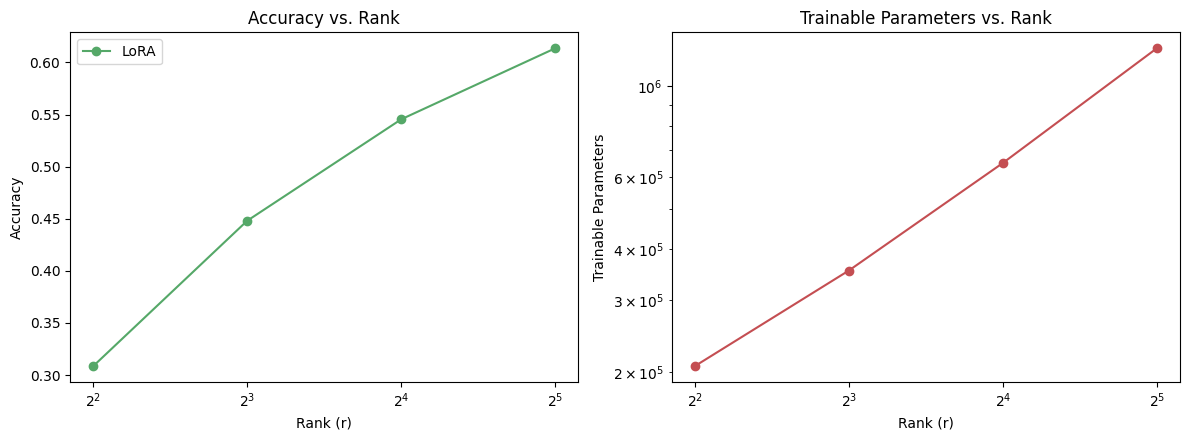

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(sweep_df["rank"], sweep_df["accuracy"], marker="o", color="#55A868", label="LoRA")
if FULL_FINETUNE_ACCURACY is not None:
    axes[0].axhline(FULL_FINETUNE_ACCURACY, color="#4C72B0", linestyle="--", label="Full fine-tune")
axes[0].set_xlabel("Rank (r)")
axes[0].set_ylabel("Accuracy")
axes[0].set_title("Accuracy vs. Rank")
axes[0].set_xscale("log", base=2)
axes[0].legend()

axes[1].plot(sweep_df["rank"], sweep_df["trainable_params"], marker="o", color="#C44E52")
axes[1].set_xlabel("Rank (r)")
axes[1].set_ylabel("Trainable Parameters")
axes[1].set_title("Trainable Parameters vs. Rank")
axes[1].set_xscale("log", base=2)
axes[1].set_yscale("log")

plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/02_rank_sweep.png", dpi=150)
plt.show()

**Read the curve, don't just eyeball it:** where does accuracy stop improving as `r` grows? That point
is the actual rank/performance trade-off — note it explicitly, with numbers, in the README.
